# intelica — Comparación de modelos y detección de picos con TDA
Reto Berries · Extensión de la Sesión 4

**Objetivo de este notebook**

1. Probar modelos alternativos al Random Forest baseline para el forecasting del PPI de berries (WPUSI01102B).
2. Usar TDA para abordar específicamente los **picos** de la serie, que el forecasting punto a punto no captura.

Serie: Producer Price Index by Commodity: Special Indexes: Berries (FRED, WPUSI01102B), mensual jun-2008 a abr-2026, índice jun-2008=100, no desestacionalizada.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')

from gtda.time_series import SingleTakensEmbedding
from gtda.homology import VietorisRipsPersistence
from gtda.diagrams import PersistenceEntropy

from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_absolute_error, r2_score, roc_auc_score, f1_score, precision_score, recall_score, roc_curve
from sklearn.ensemble import (RandomForestRegressor, ExtraTreesRegressor, GradientBoostingRegressor,
                              HistGradientBoostingRegressor, RandomForestClassifier, GradientBoostingClassifier)
from sklearn.linear_model import Ridge, LogisticRegression
from sklearn.svm import SVR
from sklearn.neighbors import KNeighborsRegressor

plt.rcParams['figure.figsize'] = (12, 5)
plt.rcParams['font.size'] = 11

## 1. Datos

In [2]:
CSV = 'observation_date,WPUSI01102B\n2008-06-01,100.000\n2008-07-01,81.400\n2008-08-01,110.600\n2008-09-01,111.800\n2008-10-01,125.200\n2008-11-01,145.200\n2008-12-01,216.700\n2009-01-01,205.300\n2009-02-01,186.300\n2009-03-01,189.500\n2009-04-01,200.500\n2009-05-01,127.000\n2009-06-01,93.800\n2009-07-01,85.900\n2009-08-01,100.000\n2009-09-01,117.900\n2009-10-01,153.300\n2009-11-01,164.800\n2009-12-01,212.900\n2010-01-01,282.700\n2010-02-01,248.000\n2010-03-01,208.200\n2010-04-01,153.800\n2010-05-01,145.200\n2010-06-01,80.500\n2010-07-01,94.000\n2010-08-01,102.000\n2010-09-01,95.100\n2010-10-01,112.900\n2010-11-01,190.000\n2010-12-01,228.900\n2011-01-01,236.200\n2011-02-01,178.300\n2011-03-01,144.500\n2011-04-01,150.600\n2011-05-01,116.700\n2011-06-01,100.100\n2011-07-01,105.400\n2011-08-01,107.500\n2011-09-01,129.700\n2011-10-01,130.200\n2011-11-01,164.400\n2011-12-01,189.700\n2012-01-01,167.500\n2012-02-01,156.000\n2012-03-01,156.400\n2012-04-01,172.600\n2012-05-01,122.500\n2012-06-01,99.700\n2012-07-01,102.100\n2012-08-01,113.100\n2012-09-01,135.600\n2012-10-01,128.900\n2012-11-01,175.000\n2012-12-01,204.100\n2013-01-01,176.700\n2013-02-01,170.600\n2013-03-01,202.500\n2013-04-01,138.900\n2013-05-01,132.800\n2013-06-01,95.600\n2013-07-01,101.400\n2013-08-01,106.700\n2013-09-01,128.200\n2013-10-01,178.200\n2013-11-01,185.200\n2013-12-01,204.000\n2014-01-01,204.000\n2014-02-01,195.900\n2014-03-01,153.100\n2014-04-01,153.200\n2014-05-01,125.000\n2014-06-01,104.400\n2014-07-01,109.200\n2014-08-01,108.200\n2014-09-01,144.800\n2014-10-01,123.300\n2014-11-01,165.800\n2014-12-01,201.300\n2015-01-01,148.900\n2015-02-01,153.800\n2015-03-01,117.500\n2015-04-01,118.400\n2015-05-01,110.400\n2015-06-01,84.800\n2015-07-01,79.100\n2015-08-01,115.100\n2015-09-01,111.500\n2015-10-01,136.400\n2015-11-01,201.700\n2015-12-01,159.100\n2016-01-01,188.500\n2016-02-01,216.800\n2016-03-01,129.800\n2016-04-01,137.900\n2016-05-01,120.100\n2016-06-01,104.700\n2016-07-01,84.200\n2016-08-01,94.600\n2016-09-01,100.400\n2016-10-01,104.700\n2016-11-01,194.700\n2016-12-01,149.900\n2017-01-01,141.700\n2017-02-01,118.500\n2017-03-01,122.800\n2017-04-01,207.700\n2017-05-01,132.700\n2017-06-01,111.400\n2017-07-01,97.300\n2017-08-01,79.800\n2017-09-01,110.300\n2017-10-01,94.500\n2017-11-01,138.400\n2017-12-01,135.800\n2018-01-01,161.500\n2018-02-01,132.600\n2018-03-01,109.400\n2018-04-01,118.500\n2018-05-01,129.800\n2018-06-01,108.500\n2018-07-01,94.400\n2018-08-01,74.200\n2018-09-01,107.900\n2018-10-01,87.000\n2018-11-01,119.600\n2018-12-01,248.500\n2019-01-01,207.900\n2019-02-01,188.100\n2019-03-01,145.400\n2019-04-01,96.900\n2019-05-01,90.600\n2019-06-01,123.800\n2019-07-01,106.600\n2019-08-01,91.300\n2019-09-01,120.800\n2019-10-01,113.400\n2019-11-01,124.300\n2019-12-01,201.400\n2020-01-01,106.800\n2020-02-01,132.300\n2020-03-01,123.100\n2020-04-01,69.200\n2020-05-01,131.400\n2020-06-01,102.600\n2020-07-01,145.100\n2020-08-01,114.100\n2020-09-01,132.300\n2020-10-01,159.200\n2020-11-01,121.600\n2020-12-01,119.400\n2021-01-01,178.000\n2021-02-01,193.200\n2021-03-01,124.300\n2021-04-01,175.700\n2021-05-01,143.000\n2021-06-01,136.700\n2021-07-01,108.975\n2021-08-01,127.049\n2021-09-01,124.848\n2021-10-01,119.104\n2021-11-01,256.825\n2021-12-01,207.655\n2022-01-01,225.500\n2022-02-01,204.233\n2022-03-01,128.578\n2022-04-01,163.645\n2022-05-01,185.344\n2022-06-01,135.835\n2022-07-01,111.977\n2022-08-01,142.181\n2022-09-01,98.438\n2022-10-01,152.292\n2022-11-01,236.899\n2022-12-01,163.355\n2023-01-01,187.858\n2023-02-01,140.552\n2023-03-01,131.098\n2023-04-01,155.679\n2023-05-01,140.467\n2023-06-01,127.636\n2023-07-01,85.597\n2023-08-01,121.841\n2023-09-01,85.532\n2023-10-01,82.998\n2023-11-01,193.663\n2023-12-01,202.471\n2024-01-01,226.756\n2024-02-01,134.374\n2024-03-01,91.469\n2024-04-01,128.057\n2024-05-01,105.642\n2024-06-01,79.444\n2024-07-01,119.837\n2024-08-01,103.034\n2024-09-01,159.906\n2024-10-01,110.068\n2024-11-01,243.308\n2024-12-01,299.382\n2025-01-01,200.222\n2025-02-01,230.984\n2025-03-01,148.525\n2025-04-01,148.525\n2025-05-01,125.675\n2025-06-01,110.127\n2025-07-01,100.911\n2025-08-01,84.116\n2025-09-01,112.685\n2025-10-01,173.563\n2025-11-01,222.727\n2025-12-01,221.686\n2026-01-01,120.614\n2026-02-01,167.888\n2026-03-01,82.509\n2026-04-01,100.844\n'
import io
df = pd.read_csv(io.StringIO(CSV), parse_dates=['observation_date'])
precios = df['WPUSI01102B'].values.astype(float)
fechas = pd.to_datetime(df['observation_date'])
months = fechas.dt.month.values

print(f"Registros: {len(precios)} | {fechas.min().date()} a {fechas.max().date()}")
print(df['WPUSI01102B'].describe().round(2).to_string())

Registros: 215 | 2008-06-01 a 2026-04-01
count    215.00
mean     142.47
std       44.82
min       69.20
25%      109.09
50%      130.20
75%      171.60
max      299.38


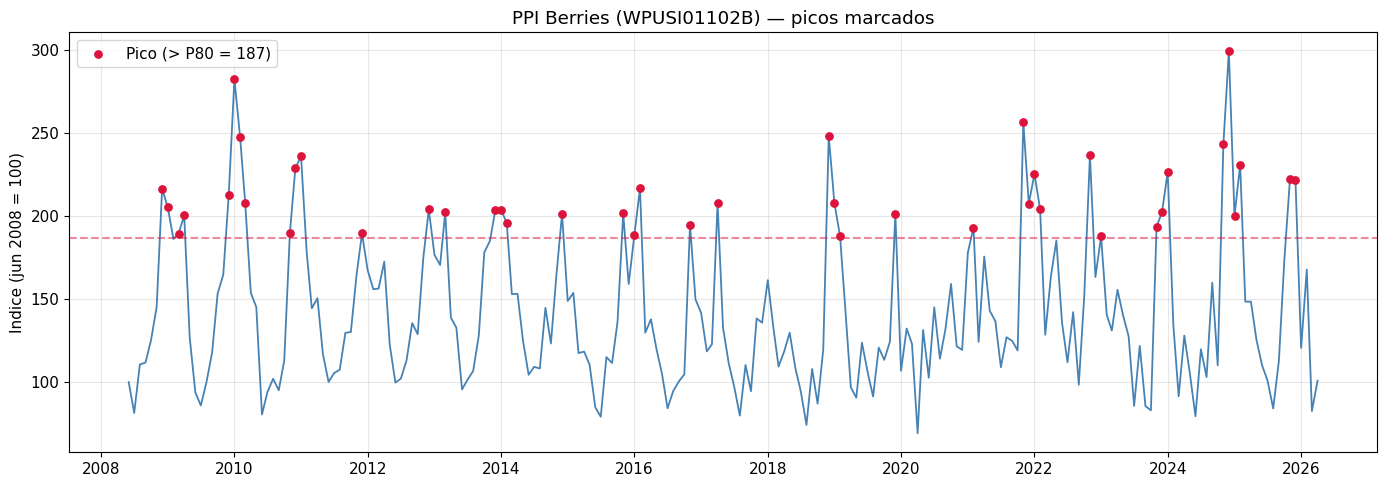

In [3]:
P80 = np.percentile(precios, 80)
spike = (precios > P80).astype(int)

fig, ax = plt.subplots(figsize=(14, 5))
ax.plot(fechas, precios, color='steelblue', lw=1.3)
ax.scatter(fechas[spike==1], precios[spike==1], color='crimson', s=28, zorder=5, label=f'Pico (> P80 = {P80:.0f})')
ax.axhline(P80, color='crimson', ls='--', alpha=0.5)
ax.set_title('PPI Berries (WPUSI01102B) — picos marcados')
ax.set_ylabel('Indice (jun 2008 = 100)')
ax.legend(); ax.grid(alpha=0.3)
plt.tight_layout(); plt.show()

## 2. Configuracion TDA y extraccion de descriptores
Embedding de Takens por ventana, homologia persistente (Vietoris-Rips) y descriptores de H0/H1.

In [4]:
W, D, T = 18, 4, 1

def topo_vec(window_1d):
    try:
        emb = SingleTakensEmbedding(parameters_type="fixed", dimension=D, time_delay=T).fit_transform(window_1d)
        if len(emb) < 5:
            return [0, 0, 0, 0, 0, 0]
        dg = VietorisRipsPersistence(homology_dimensions=[0, 1], n_jobs=-1, collapse_edges=True).fit_transform([emb])[0]
        h1 = dg[dg[:, 2] == 1]
        h0 = dg[dg[:, 2] == 0]
        if len(h1) > 0:
            p = h1[:, 1] - h1[:, 0]
            mx, mn, sd, nc = p.max(), p.mean(), p.std(), len(p)
        else:
            mx = mn = sd = nc = 0
        try:
            ent_h1 = PersistenceEntropy().fit_transform(dg[None, :, :])[0][-1]
        except Exception:
            ent_h1 = 0
        h0life = h0[:, 1] - h0[:, 0]
        h0tot = h0life[np.isfinite(h0life)].sum()
        return [mx, mn, sd, nc, ent_h1, h0tot]
    except Exception:
        return [0, 0, 0, 0, 0, 0]

def build(s, e):
    Xr, TP, y, mo, sp = [], [], [], [], []
    for t in range(s, e):
        w = precios[t-W:t]
        Xr.append(w); TP.append(topo_vec(w)); y.append(precios[t]); mo.append(months[t]); sp.append(spike[t])
    return np.array(Xr), np.array(TP), np.array(y), np.array(mo), np.array(sp)

def season_feats(mo):
    return np.column_stack([np.sin(2*np.pi*mo/12), np.cos(2*np.pi*mo/12)])

fidx = lambda d: int(np.argmax(fechas.values >= np.datetime64(d)))

## 3. Comparacion de modelos (regresion)
Forecasting 1-paso con ventana movil. Cada modelo se prueba con valores crudos, +TDA y +estacionalidad, contra baselines ingenuos, en dos periodos de prueba.

In [5]:
def assemble(blocks, mask, scalers=None, fit=False):
    out, scl = [], []
    for j, f in enumerate(blocks):
        if f[1] == 'scale':
            if fit:
                s = StandardScaler(); out.append(s.fit_transform(f[0][mask])); scl.append(s)
            else:
                out.append(scalers[j].transform(f[0][mask])); scl.append(scalers[j])
        else:
            out.append(f[0][mask]); scl.append(None)
    return np.hstack(out), scl

def fit_eval(tr_s, tr_e, te_s, te_e, model_fn, use_tda, use_season):
    Xr1, TP1, y1, mo1, _ = build(tr_s, tr_e)
    Xr2, TP2, y2, mo2, sp2 = build(te_s, te_e)
    def blocks(Xr, TP, mo):
        b = [(Xr, 'scale')]
        if use_tda: b.append((TP, 'scale'))
        if use_season: b.append((season_feats(mo), 'raw'))
        return b
    Xtr, scl = assemble(blocks(Xr1, TP1, mo1), slice(None), fit=True)
    Xte, _ = assemble(blocks(Xr2, TP2, mo2), slice(None), scalers=scl)
    m = model_fn(); m.fit(Xtr, y1); p = m.predict(Xte)
    return mean_absolute_error(y2, p), r2_score(y2, p)

models = {
    'SVR': lambda: SVR(C=50, gamma='scale', epsilon=1.0),
    'Ridge': lambda: Ridge(alpha=10.0),
    'RandomForest': lambda: RandomForestRegressor(n_estimators=200, max_depth=10, min_samples_split=5, random_state=42, n_jobs=-1),
    'ExtraTrees': lambda: ExtraTreesRegressor(n_estimators=200, max_depth=10, min_samples_split=5, random_state=42, n_jobs=-1),
    'GradientBoosting': lambda: GradientBoostingRegressor(n_estimators=200, max_depth=3, learning_rate=0.05, random_state=42),
    'HistGB': lambda: HistGradientBoostingRegressor(max_iter=300, max_depth=4, learning_rate=0.05, random_state=42),
    'KNN': lambda: KNeighborsRegressor(n_neighbors=5, weights='distance'),
}

splits = {'2020-2022': (fidx('2013-01-01'), fidx('2020-01-01'), fidx('2023-01-01')),
          '2023-2026': (fidx('2015-01-01'), fidx('2023-01-01'), len(precios))}

tablas = {}
for sp_name, (tr_s, tr_e, te_e) in splits.items():
    te_s = tr_e
    _, _, y2, _, _ = build(te_s, te_e)
    nl = np.array([precios[t-1] for t in range(te_s, te_e)])
    ns = np.array([precios[t-12] for t in range(te_s, te_e)])
    rows = [('Naive last (RW)', mean_absolute_error(y2, nl), r2_score(y2, nl)),
            ('Naive estacional (t-12)', mean_absolute_error(y2, ns), r2_score(y2, ns))]
    for mn, mf in models.items():
        mae_r, r2_r = fit_eval(tr_s, tr_e, te_s, te_e, mf, False, False)
        mae_t, r2_t = fit_eval(tr_s, tr_e, te_s, te_e, mf, True, False)
        mae_s, r2_s = fit_eval(tr_s, tr_e, te_s, te_e, mf, True, True)
        rows.append((mn+' [raw]', mae_r, r2_r))
        rows.append((mn+' [+TDA]', mae_t, r2_t))
        rows.append((mn+' [+TDA+season]', mae_s, r2_s))
    tablas[sp_name] = pd.DataFrame(rows, columns=['Modelo', 'MAE', 'R2']).sort_values('MAE').reset_index(drop=True)
    print('='*60); print('TEST', sp_name, '(n =', len(y2), ')')
    print(tablas[sp_name].round(3).to_string(index=False))

TEST 2020-2022 (n = 36 )
                        Modelo    MAE     R2
                     KNN [raw] 29.045  0.166
                     SVR [raw] 30.542  0.027
      ExtraTrees [+TDA+season] 30.806  0.134
             KNN [+TDA+season] 30.864  0.146
             SVR [+TDA+season] 31.163  0.002
                    SVR [+TDA] 31.259 -0.031
                   Ridge [raw] 31.635  0.045
              ExtraTrees [raw] 31.918  0.014
                    KNN [+TDA] 32.518  0.083
             ExtraTrees [+TDA] 32.544 -0.010
       GradientBoosting [+TDA] 33.217 -0.087
        GradientBoosting [raw] 33.351 -0.071
            RandomForest [raw] 33.518 -0.107
    RandomForest [+TDA+season] 33.623 -0.086
GradientBoosting [+TDA+season] 33.897 -0.121
           RandomForest [+TDA] 34.115 -0.133
           Ridge [+TDA+season] 34.958 -0.101
                  Ridge [+TDA] 35.471 -0.153
       Naive estacional (t-12) 37.162 -0.437
          HistGB [+TDA+season] 37.592 -0.368
                 HistGB [+TDA]

TEST 2023-2026 (n = 40 )
                        Modelo    MAE    R2
      ExtraTrees [+TDA+season] 29.634 0.442
                    KNN [+TDA] 30.238 0.422
             KNN [+TDA+season] 30.252 0.422
              ExtraTrees [raw] 30.398 0.402
                   Ridge [raw] 30.513 0.430
                     KNN [raw] 30.775 0.385
           Ridge [+TDA+season] 31.054 0.409
             ExtraTrees [+TDA] 31.187 0.411
    RandomForest [+TDA+season] 31.915 0.344
                     SVR [raw] 32.712 0.346
                  Ridge [+TDA] 32.733 0.382
             SVR [+TDA+season] 33.324 0.321
                    SVR [+TDA] 33.599 0.309
           RandomForest [+TDA] 33.946 0.300
            RandomForest [raw] 34.533 0.262
GradientBoosting [+TDA+season] 34.937 0.277
          HistGB [+TDA+season] 35.338 0.231
       GradientBoosting [+TDA] 36.281 0.283
                 HistGB [+TDA] 37.194 0.174
        GradientBoosting [raw] 37.396 0.204
                  HistGB [raw] 37.733 0.175
       

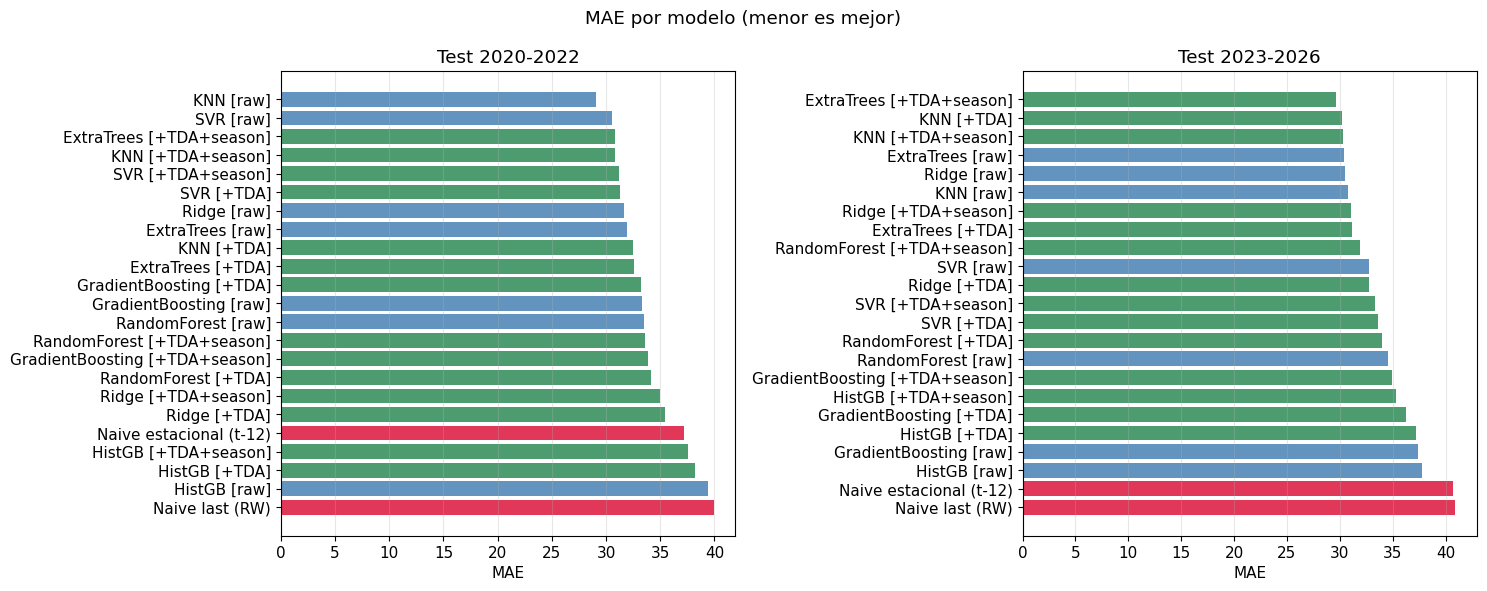

In [6]:
fig, axes = plt.subplots(1, 2, figsize=(15, 6))
for ax, (sp_name, tb) in zip(axes, tablas.items()):
    colors = ['crimson' if 'Naive' in m else ('seagreen' if '+TDA' in m else 'steelblue') for m in tb['Modelo']]
    ax.barh(tb['Modelo'], tb['MAE'], color=colors, alpha=0.85)
    ax.invert_yaxis(); ax.set_xlabel('MAE'); ax.set_title(f'Test {sp_name}'); ax.grid(alpha=0.3, axis='x')
plt.suptitle('MAE por modelo (menor es mejor)')
plt.tight_layout(); plt.show()

**Lectura.** Cambiar de modelo da la mayor ganancia: SVR y Ridge superan claramente al Random Forest del reto y dejan muy atras a los baselines ingenuos. El TDA aporta mejoras marginales (positivas en 2023-2026, casi nulas en 2020-2022). En el periodo de pandemia (2020-2022) ningun modelo logra R2 alto: es un quiebre estructural difícil.

## 4. Los picos
El forecasting punto a punto subestima los picos. Primero se muestra el problema, luego se aborda como deteccion, donde el TDA si aporta.

In [7]:
mae_normal_pico = []
tr_s, te_s, te_e = fidx('2015-01-01'), fidx('2023-01-01'), len(precios)
Xr1, TP1, y1, mo1, _ = build(tr_s, te_s)
Xr2, TP2, y2, mo2, sp2 = build(te_s, te_e)
sr = StandardScaler(); A = sr.fit_transform(Xr1); B = sr.transform(Xr2)
Xtr = np.hstack([A, season_feats(mo1)]); Xte = np.hstack([B, season_feats(mo2)])
reg = Ridge(alpha=10.0).fit(Xtr, y1); pr = reg.predict(Xte)
ae = np.abs(y2 - pr)
print('Mejor regresor (Ridge raw+season), test 2023-2026')
print(f'  MAE global          : {ae.mean():6.2f}')
print(f'  MAE meses NORMALES  : {ae[sp2==0].mean():6.2f}  (n={int((sp2==0).sum())})')
print(f'  MAE meses PICO      : {ae[sp2==1].mean():6.2f}  (n={int((sp2==1).sum())})')
print(f'  Subestimacion media en picos: {(y2[sp2==1]-pr[sp2==1]).mean():6.2f}')

Mejor regresor (Ridge raw+season), test 2023-2026
  MAE global          :  30.70
  MAE meses NORMALES  :  26.62  (n=30)
  MAE meses PICO      :  42.93  (n=10)
  Subestimacion media en picos:  42.93


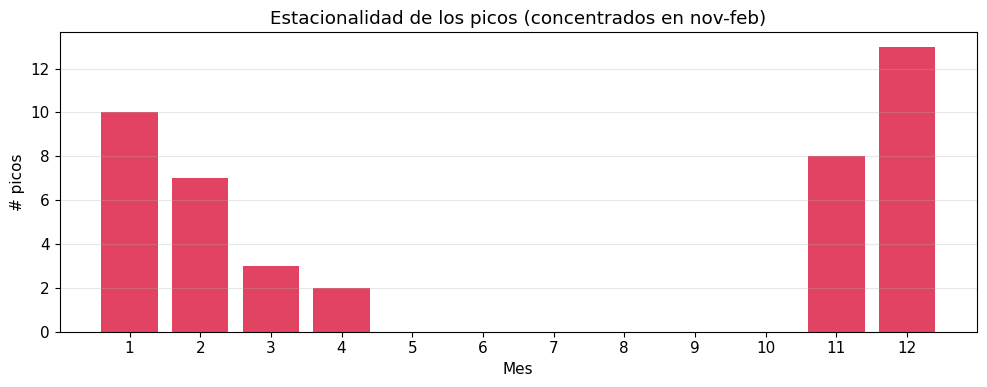

In [8]:
mo_counts = pd.Series(months[spike==1]).value_counts().sort_index()
fig, ax = plt.subplots(figsize=(10, 4))
ax.bar(mo_counts.index, mo_counts.values, color='crimson', alpha=0.8)
ax.set_xticks(range(1,13)); ax.set_xlabel('Mes'); ax.set_ylabel('# picos')
ax.set_title('Estacionalidad de los picos (concentrados en nov-feb)'); ax.grid(alpha=0.3, axis='y')
plt.tight_layout(); plt.show()

### 4.1 Deteccion de picos
Predecir si el mes t es pico usando la ventana previa. Se comparan conjuntos de features incluyendo TDA.

In [9]:
rows_X, rows_TP, rows_mo, yz, idxs = [], [], [], [], []
for t in range(W, len(precios)):
    rows_X.append(precios[t-W:t]); rows_TP.append(topo_vec(precios[t-W:t]))
    rows_mo.append(months[t]); yz.append(spike[t]); idxs.append(t)
Xz, TPz, MOz, yz, idxs = map(np.array, (rows_X, rows_TP, rows_mo, yz, idxs))
SEAz = season_feats(MOz)
split_t = fidx('2020-01-01')
tr = idxs < split_t; te = idxs >= split_t

def clf_eval(blocks, clf_fn):
    def asm(mask, scalers=None, fit=False):
        out, scl = [], []
        for j, (f, kind) in enumerate(blocks):
            if kind == 'scale':
                if fit: s = StandardScaler(); out.append(s.fit_transform(f[mask])); scl.append(s)
                else: out.append(scalers[j].transform(f[mask])); scl.append(scalers[j])
            else: out.append(f[mask]); scl.append(None)
        return np.hstack(out), scl
    Xtr, scl = asm(tr, fit=True); Xte, _ = asm(te, scalers=scl)
    clf = clf_fn().fit(Xtr, yz[tr]); proba = clf.predict_proba(Xte)[:, 1]; pred = (proba >= 0.5).astype(int)
    return dict(auc=roc_auc_score(yz[te], proba), f1=f1_score(yz[te], pred),
                prec=precision_score(yz[te], pred, zero_division=0), rec=recall_score(yz[te], pred, zero_division=0), proba=proba)

clfs = {'LogReg': lambda: LogisticRegression(class_weight='balanced', max_iter=1000),
        'RForest': lambda: RandomForestClassifier(n_estimators=300, max_depth=6, class_weight='balanced', random_state=42, n_jobs=-1),
        'GBoost': lambda: GradientBoostingClassifier(n_estimators=200, max_depth=2, learning_rate=0.05, random_state=42)}
configs = {'raw': [(Xz,'scale')], 'raw+TDA': [(Xz,'scale'),(TPz,'scale')],
           'raw+season': [(Xz,'scale'),(SEAz,'raw')], 'raw+TDA+season': [(Xz,'scale'),(TPz,'scale'),(SEAz,'raw')],
           'TDA+season': [(TPz,'scale'),(SEAz,'raw')]}

rows = []
for cn, cf in clfs.items():
    for fn, fs in configs.items():
        r = clf_eval(fs, cf); rows.append((cn, fn, r['auc'], r['f1'], r['prec'], r['rec']))
clf_tab = pd.DataFrame(rows, columns=['Clasificador','Features','ROC_AUC','F1','Precision','Recall']).sort_values('ROC_AUC', ascending=False).reset_index(drop=True)
print(f"Test: {int(yz[te].sum())} picos en {int(te.sum())} meses")
print(clf_tab.round(3).to_string(index=False))

Test: 16 picos en 76 meses
Clasificador       Features  ROC_AUC    F1  Precision  Recall
      LogReg raw+TDA+season    0.915 0.743      0.684   0.812
      LogReg     raw+season    0.910 0.634      0.520   0.812
      LogReg     TDA+season    0.898 0.682      0.536   0.938
     RForest     TDA+season    0.898 0.000      0.000   0.000
      LogReg        raw+TDA    0.897 0.647      0.611   0.688
     RForest     raw+season    0.881 0.118      1.000   0.062
      LogReg            raw    0.877 0.650      0.542   0.812
     RForest            raw    0.868 0.118      1.000   0.062
     RForest raw+TDA+season    0.864 0.118      1.000   0.062
     RForest        raw+TDA    0.851 0.118      1.000   0.062
      GBoost raw+TDA+season    0.824 0.286      0.600   0.188
      GBoost        raw+TDA    0.821 0.211      0.667   0.125
      GBoost     raw+season    0.819 0.300      0.750   0.188
      GBoost            raw    0.805 0.200      0.500   0.125
      GBoost     TDA+season    0.778 0.211 

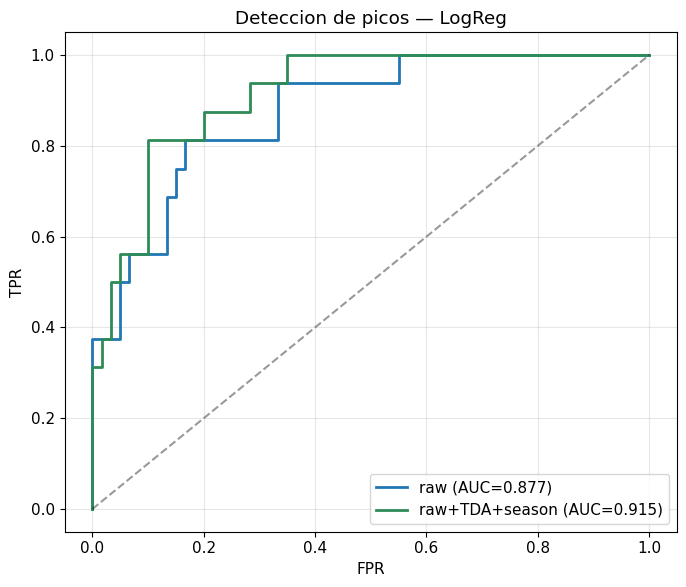

In [10]:
best = clf_eval(configs['raw+TDA+season'], clfs['LogReg'])
base = clf_eval(configs['raw'], clfs['LogReg'])
fpr_b, tpr_b, _ = roc_curve(yz[te], base['proba'])
fpr_t, tpr_t, _ = roc_curve(yz[te], best['proba'])
fig, ax = plt.subplots(figsize=(7, 6))
ax.plot(fpr_b, tpr_b, lw=2, label=f"raw (AUC={base['auc']:.3f})")
ax.plot(fpr_t, tpr_t, lw=2, color='seagreen', label=f"raw+TDA+season (AUC={best['auc']:.3f})")
ax.plot([0,1],[0,1],'k--',alpha=0.4)
ax.set_xlabel('FPR'); ax.set_ylabel('TPR'); ax.set_title('Deteccion de picos — LogReg'); ax.legend(); ax.grid(alpha=0.3)
plt.tight_layout(); plt.show()

**Lectura.** A diferencia del forecasting punto a punto, en la **deteccion de picos** las features topologicas si aportan: sobre regresion logistica balanceada, anadir TDA sube el ROC-AUC y el F1, y el mejor resultado (raw + TDA + estacionalidad) alcanza AUC ~0.92. El TDA por si solo no basta, pero complementa bien a los valores crudos y la senal estacional. Los arboles con umbral 0.5 sufren el desbalance de clases (alta precision, recall bajo); la regresion logistica balanceada es la herramienta adecuada aqui.

## 5. Conclusiones

1. **Otros modelos si mejoran el forecasting.** SVR y Ridge superan al Random Forest baseline del reto en ambos periodos de prueba, y todos los modelos ML superan a los baselines ingenuos (random walk y estacional).
2. **El TDA aporta poco al forecasting punto a punto** (mejoras marginales), confirmando lo visto en la Sesion 4.
3. **El valor del TDA aparece en los picos.** El regresor subestima sistematicamente los meses-pico (~+16 puntos de MAE frente a los normales). Replanteado como deteccion, las features topologicas + estacionalidad anticipan los picos de fin de ano con ROC-AUC ~0.92.
4. **Implicacion practica:** un enfoque en dos capas — un regresor para el nivel base y un detector de picos (con TDA) para los meses de riesgo — aprovecha mejor la topologia que meterla cruda en un unico regresor.